# تقييم النماذج والرسوم البيانية (Model Evaluation & Visualization)

يهدف هذا الملف إلى تحليل أداء نماذج اكتشاف الشذوذ (Unsupervised) بصرياً ومقارنة نتائجها باستخدام مقاييس مناسبة لمشكلة الاحتيال المالي، مع التركيز على مصفوفة الارتباك ومنحنيات الدقة والاستدعاء.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    precision_recall_curve, 
    average_precision_score, 
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

# إعدادات الرسوم البيانية
%matplotlib inline
sns.set_theme(style="whitegrid")

# تحميل البيانات وتجهيز مجموعة الاختبار
df = pd.read_csv("../data/creditcard.csv")
normal_data = df[df['Class'] == 0]
fraud_data = df[df['Class'] == 1]

_, X_test_normal = train_test_split(normal_data.drop('Class', axis=1), test_size=0.2, random_state=42)
X_test = pd.concat([X_test_normal, fraud_data.drop('Class', axis=1)])
y_test = np.concatenate([np.zeros(len(X_test_normal)), np.ones(len(fraud_data))])

# تحميل النموذج الأفضل
model = joblib.load('../models/best_model.pkl')

## 1. مصفوفة الارتباك (Confusion Matrix)
سنرى كيف نجح النموذج في اكتشاف حالات الاحتيال (Class 1) مقارنة بالحالات السليمة.

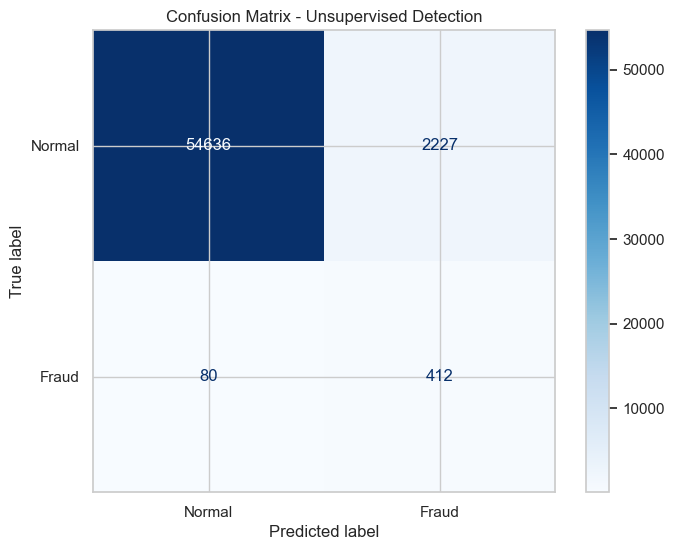

In [5]:
y_pred = model.predict(X_test)
# تحويل مخرجات Isolation Forest (-1, 1) إلى (1, 0)
y_pred_binary = [1 if x == -1 else 0 for x in y_pred]

cm = confusion_matrix(y_test, y_pred_binary)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Unsupervised Detection')
plt.show()

## 2. منحنى الدقة والاستدعاء (Precision-Recall Curve)
في حالات البيانات غير المتوازنة، يعتبر منحنى PR أكثر دقة من منحنى ROC.

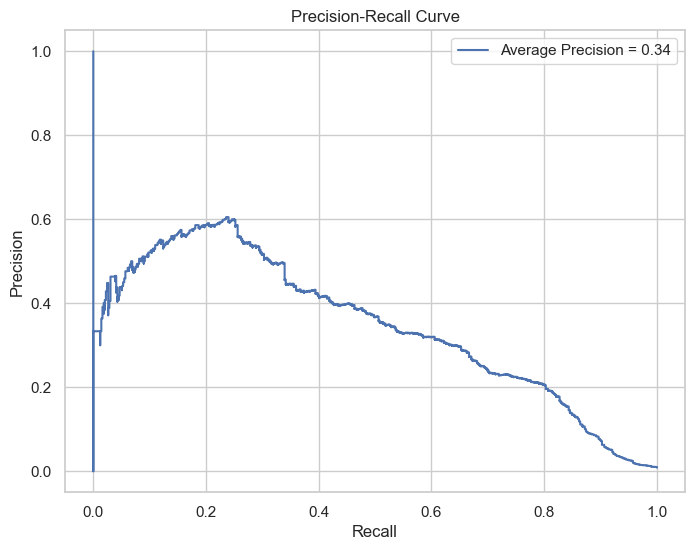

In [6]:
# الحصول على درجات الشذوذ (Anomaly Scores)
# Isolation Forest يعيد درجات حيث القيم الأقل تعني شذوذ أكثر
scores = model.decision_function(X_test)
# نحولها بحيث القيم الأعلى تعني احتمالية احتيال أعلى
fraud_scores = -scores 

precision, recall, _ = precision_recall_curve(y_test, fraud_scores)
avg_precision = average_precision_score(y_test, fraud_scores)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, where='post', label=f'Average Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 3. تحليل النتائج
بناءً على الرسوم البيانية، يمكننا تحديد مدى كفاءة النموذج في عزل العمليات الاحتيالية عن العمليات الطبيعية باستخدام البيانات السليمة فقط للتدريب.